<a href="https://colab.research.google.com/github/jurados/MLOps/blob/main/Homeworks/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
print(f"Pandas Version: {pd.__version__}")

Pandas Version: 2.2.3


In [6]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-09-15 17:15:00--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.06s   

2026-09-15 17:15:00 (9.33 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [8]:
data  = pd.read_csv("car_fuel_efficiency_2026.csv")
data.shape, data.columns, data.head(5)

((10000, 11),
 Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
        'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
        'acceleration', 'fuel_efficiency_mpg'],
       dtype='object'),
    model_year  origin fuel_type         drivetrain  num_doors  \
 0        2006  Europe  Gasoline  Front-wheel drive          4   
 1        2008  Europe    Diesel  Front-wheel drive          4   
 2        1996    Asia  Gasoline  Front-wheel drive          5   
 3        1989  Europe  Gasoline  Front-wheel drive          4   
 4        1994     USA    Diesel  Front-wheel drive          3   
 
    engine_displacement  num_cylinders  horsepower  vehicle_weight  \
 0                 2180              6       243.0            3870   
 1                 2390              6       272.0            4210   
 2                 2320              6       267.0            4240   
 3                 2130              6       258.0            4490   
 4            

In [21]:
data.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


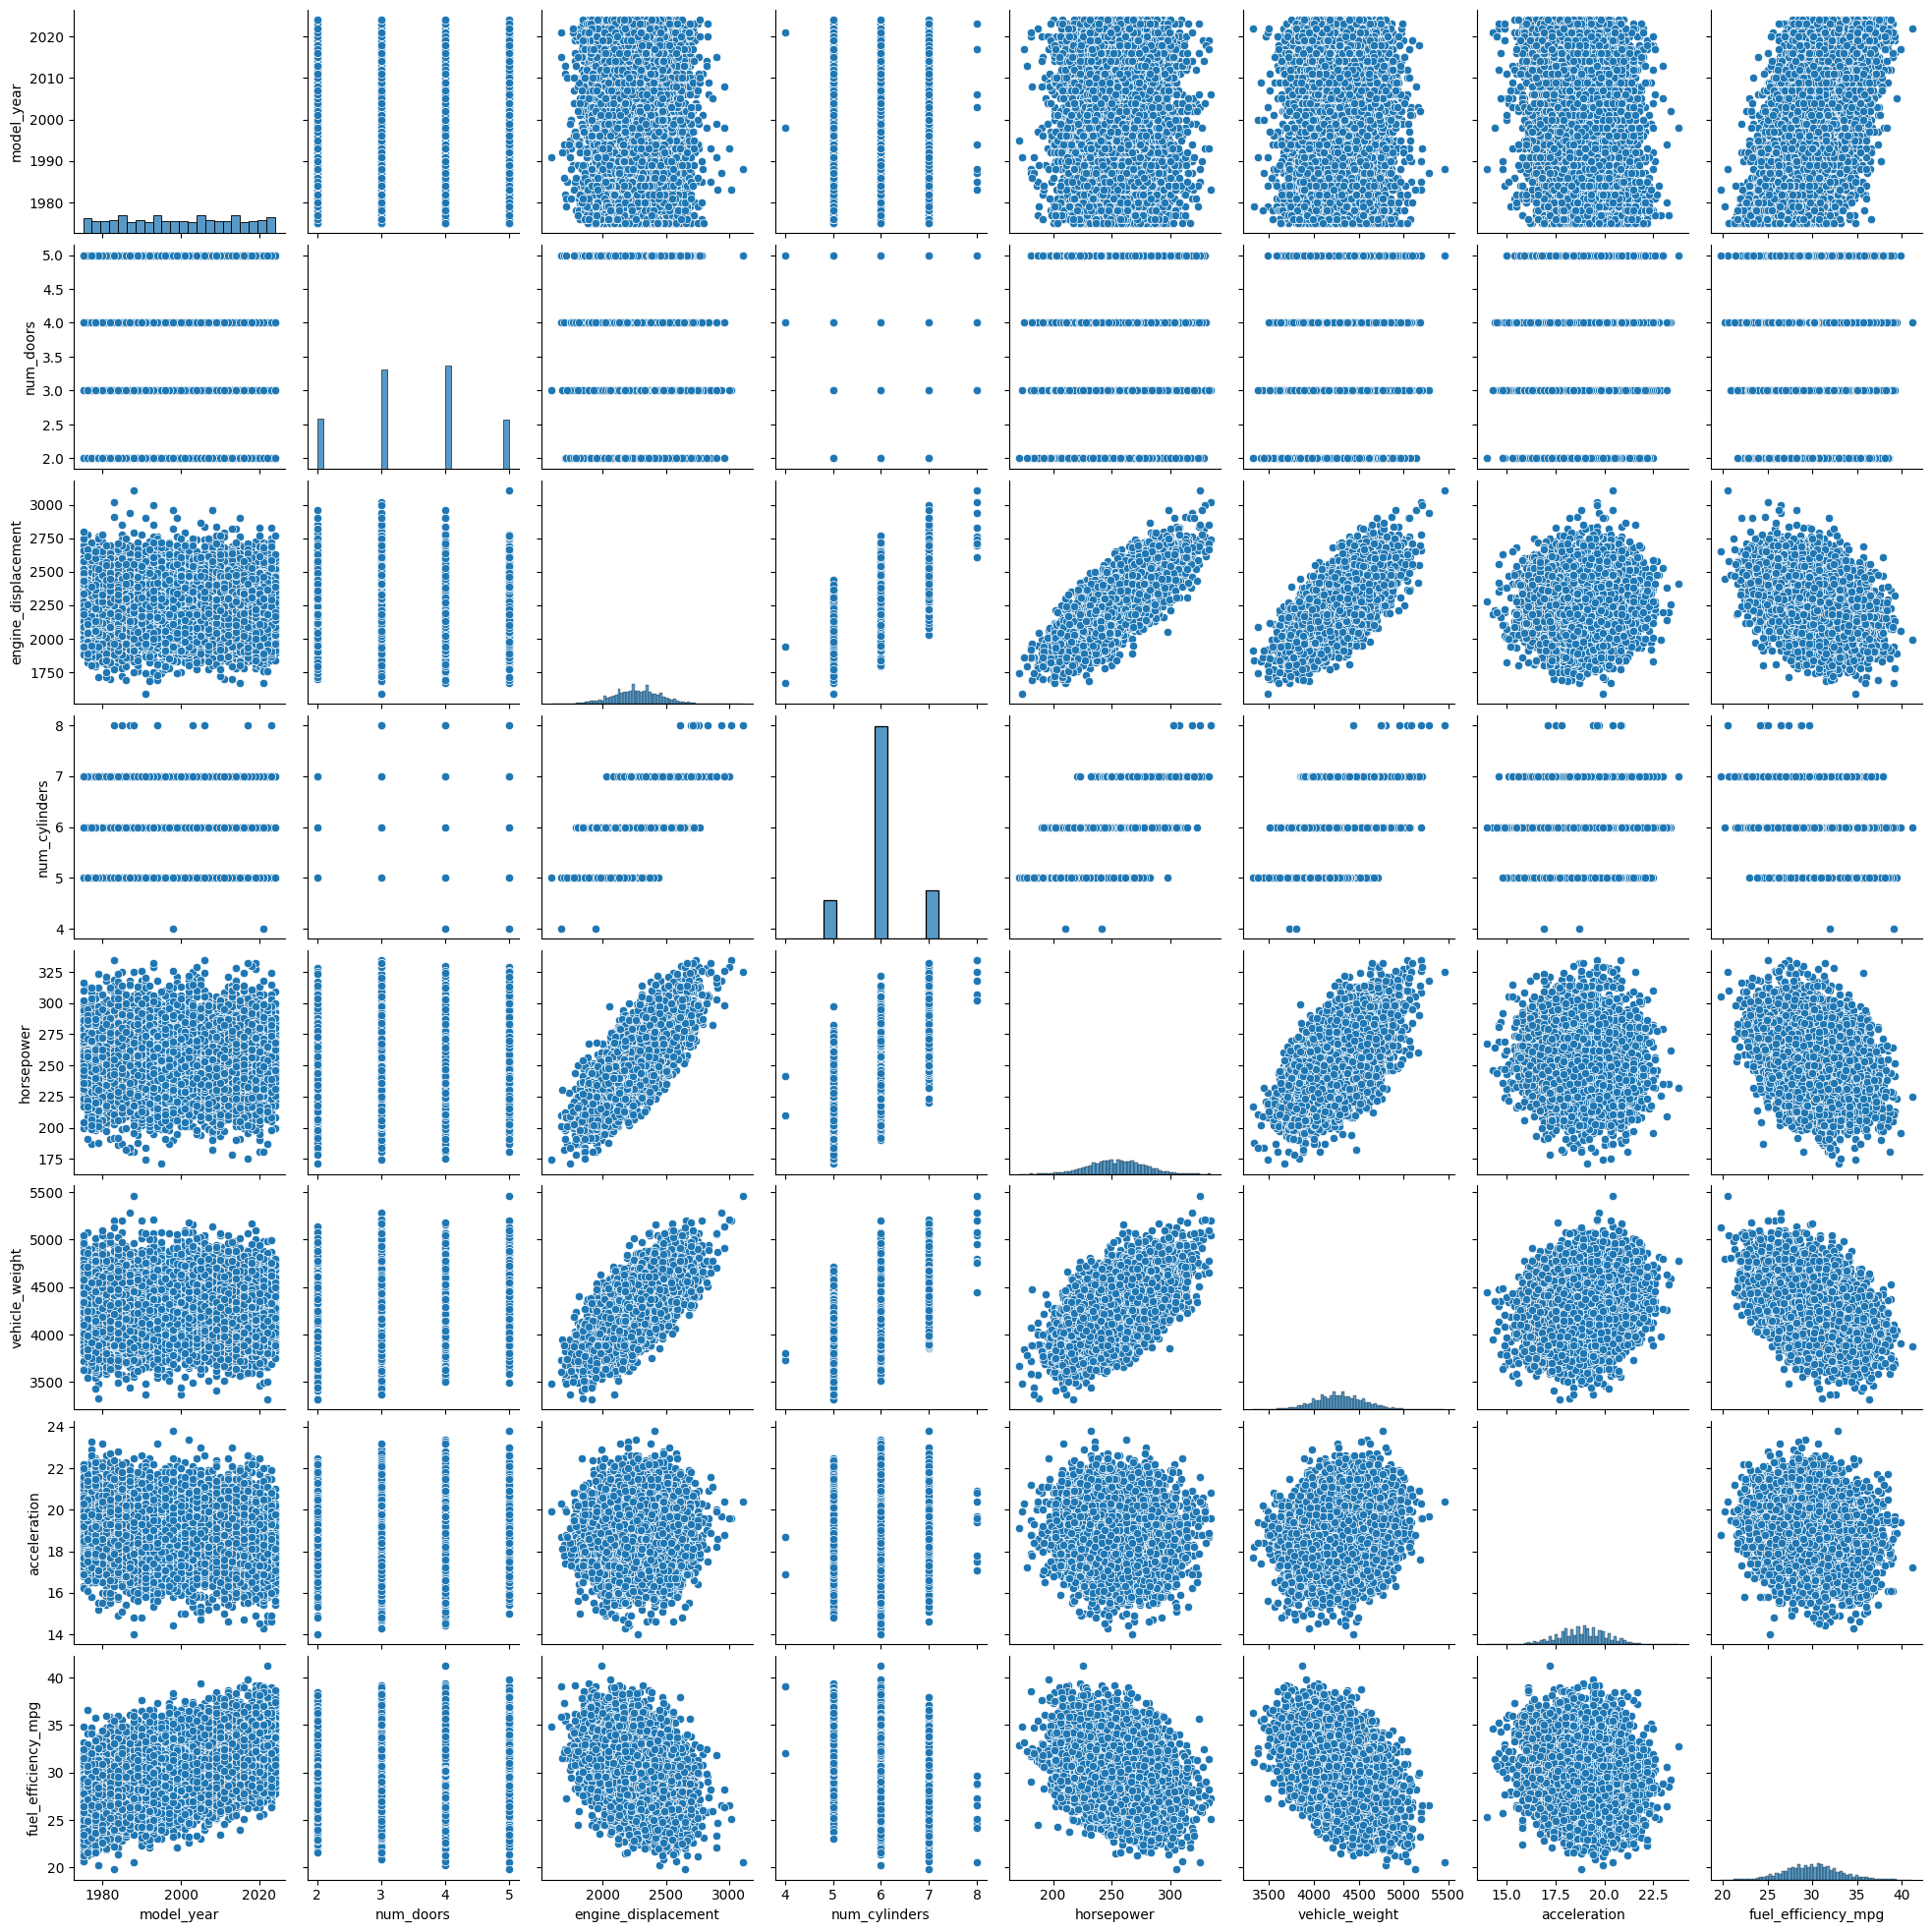

In [11]:
sns.pairplot(data)

In [40]:
# Q2. Records count
# How many records are in the dataset?
print(f"There are {data.shape[0]} records in the dataset")

There are 10000 records in the dataset


In [41]:
# Q3. Fuel types
# How many fuel types are presented in the dataset?
print(f'There are {data.fuel_type.nunique()} fuel types: {data.fuel_type.unique()}')

There are 3 fuel types: ['Gasoline' 'Diesel' 'Hybrid']


In [42]:
# Q4. Missing Values
# How many columns in the dataset have missing values?
nancolumn = data.isna().any().sum()
print(f"There are {nancolumn} columns with missing values")


There are 2 columns with missing values


In [43]:
# Q5. Max fuel efficiency
# What's the maximum fuel efficiency of cars from Asia?
print(f"The maximum fule efficiency is {data.fuel_efficiency_mpg.max()} mpg")

The maximum fule efficiency is 41.2 mpg


In [59]:
# Q6. Median value of horsepower
# Find the median value of the horsepower column in the dataset.
median_horsepower = data.horsepower.median()

# Next, calculate the most frequent value of the same horsepower column.
most_frequent_horsepower = data.horsepower.mode()[0]
print(
    f"The median value of horsepower is {median_horsepower} " \
    f"and the most frequent value is {most_frequent_horsepower}"
)

# Use the fillna method to fill the missing values in the horsepower column
# with the most frequent value from the previous step.
data.horsepower = data.horsepower.fillna(most_frequent_horsepower)

# Now, calculate the median value of horsepower once again.
second_median_horsepower = data.horsepower.median()
print(f"The new median value of horsepower is {second_median_horsepower}")

# Has it changed?
sign = "<" if second_median_horsepower < median_horsepower else ">"
print(f"The new median value {second_median_horsepower} {sign} {median_horsepower} the old one")

The median value of horsepower is 254.0 and the most frequent value is 252.0
The new median value of horsepower is 252.0
The new median value 252.0 < 254.0 the old one


In [106]:
#Q7. Sum of weights
# Select all the cars from Asia
asia_car = data[data.origin == "Asia"].reset_index(drop=True)

# Select only columns vehicle_weight and model_year
subset_asia_car = asia_car[["vehicle_weight", "model_year"]]

# Select the first 7 values
top7 = subset_asia_car[:7]
print(top7, end='\n')
print()

# Get the underlying NumPy array. Let's call it X
X = top7.to_numpy()
print(f"X={X}")
print()

# Compute matrix-matrix multiplication between the transpose of X and X
xtx = X.T @ X
print(f"The matrix-matrix multiplication between X^T and X is \n{xtx}{xtx.shape}")
print()

# Compute the inverse of XTX
xtx_inv = np.linalg.inv(xtx)
print(f"The inverse of X^TX is \n{xtx_inv}{xtx_inv.shape}")
print()
# Create an array y
y = np.asarray([1100, 1300, 800, 900, 1000, 1100, 1200])

# The result
w = xtx_inv @ X.T @ y
print(f'The weights are:\n{w}')

# What's the sum of all the elements of the result?
print(f'The sum of all the elements of the result is {w.sum():.3f}')

   vehicle_weight  model_year
0            4240        1996
1            4310        1992
2            4230        1997
3            4420        1978
4            3950        2007
5            4750        2021
6            4450        2019

X=[[4240 1996]
 [4310 1992]
 [4230 1997]
 [4420 1978]
 [3950 2007]
 [4750 2021]
 [4450 2019]]

The matrix-matrix multiplication between X^T and X is 
[[131950500  60750580]
 [ 60750580  28041424]](2, 2)

The inverse of X^TX is 
[[ 2.96830537e-06 -6.43071025e-06]
 [-6.43071025e-06  1.39675281e-05]](2, 2)

The weights are:
[0.13644777 0.2327492 ]
The sum of all the elements of the result is 0.369
